In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

In [3]:
unfair = pd.read_csv('../benchmark/balanced-stroke-age-result/unfair_lr-100.csv', index_col=0)
zhang = pd.read_csv('../benchmark/balanced-stroke-age-result/zhang-100.csv', index_col=0)

In [4]:
unfair = unfair.drop([0,1,2,3,4], axis=0)
unfair

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
5,UnfairLR,13,0.9094,0.4976,0.8591,0.9367,0.6433,0.8836,0.9229,257.0000,75.0000,106.0000,907.0000,1070.0000,8.0000,66.0000,327.0000
6,UnfairLR,29,0.8977,0.4535,0.7791,0.9215,0.6026,0.8342,0.9094,212.0000,125.0000,90.0000,951.0000,1036.0000,8.0000,65.0000,329.0000
7,UnfairLR,42,0.8995,0.4647,0.8115,0.8733,0.6128,0.8532,0.8862,228.0000,78.0000,106.0000,900.0000,1094.0000,5.0000,94.0000,311.0000
8,UnfairLR,55,0.8977,0.4287,0.7521,0.8846,0.5802,0.8185,0.8911,213.0000,136.0000,71.0000,930.0000,1075.0000,10.0000,71.0000,310.0000
9,UnfairLR,73,0.9070,0.4982,0.8616,0.8950,0.6431,0.8837,0.9009,273.0000,57.0000,118.0000,914.0000,1061.0000,1.0000,86.0000,306.0000


In [5]:
zhang

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,Zhang4DP,13,0.8920,0.5208,0.8688,0.9181,0.6576,0.8803,0.9049,265.0000,67.0000,131.0000,882.0000,1055.0000,23.0000,83.0000,310.0000
1,Zhang4DP,29,0.8903,0.4880,0.8192,0.8922,0.6304,0.8533,0.8912,246.0000,91.0000,115.0000,926.0000,1027.0000,17.0000,86.0000,308.0000
2,Zhang4DP,42,0.8771,0.4488,0.7609,0.8223,0.5938,0.8149,0.8489,204.0000,102.0000,97.0000,909.0000,1063.0000,36.0000,111.0000,294.0000
3,Zhang4DP,55,0.8729,0.4234,0.7142,0.8565,0.5703,0.7856,0.8646,188.0000,161.0000,77.0000,924.0000,1049.0000,36.0000,84.0000,297.0000
4,Zhang4DP,73,0.8775,0.4717,0.7849,0.8752,0.6136,0.8286,0.8764,214.0000,116.0000,95.0000,937.0000,1013.0000,49.0000,85.0000,307.0000
5,Zhang4EqOdds,13,0.8892,0.5164,0.8590,0.9166,0.6534,0.8738,0.9027,259.0000,73.0000,132.0000,881.0000,1055.0000,23.0000,84.0000,309.0000
6,Zhang4EqOdds,29,0.8849,0.5028,0.8315,0.9110,0.6413,0.8574,0.8978,245.0000,92.0000,124.0000,917.0000,1018.0000,26.0000,82.0000,312.0000
7,Zhang4EqOdds,42,0.8736,0.4607,0.7721,0.8323,0.6033,0.8197,0.8524,207.0000,99.0000,107.0000,899.0000,1060.0000,39.0000,111.0000,294.0000
8,Zhang4EqOdds,55,0.8725,0.4198,0.7091,0.8482,0.5669,0.7823,0.8602,187.0000,162.0000,74.0000,927.0000,1048.0000,37.0000,86.0000,295.0000
9,Zhang4EqOdds,73,0.8757,0.4713,0.7826,0.8654,0.6128,0.8265,0.8705,216.0000,114.0000,98.0000,934.0000,1014.0000,48.0000,90.0000,302.0000


## Acc mean and std

In [6]:
unfair_acc = unfair.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([unfair_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,UnfairLR,0.9023,0.0055
1,Zhang4DP,0.8820,0.0086
2,Zhang4EqOdds,0.8792,0.0074
3,Zhang4EqOpp,0.9012,0.0065


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['UnfairLR', 'Zhang4DP', 'Zhang4EqOdds', 'Zhang4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,UnfairLR,0.9023,0.0055
1,Zhang4DP,0.8820,0.0086
2,Zhang4EqOdds,0.8792,0.0074
3,Zhang4EqOpp,0.9012,0.0065


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

0.9023 $\pm$ 0.0055
 0.882 $\pm$ 0.0086
0.8792 $\pm$ 0.0074
0.9012 $\pm$ 0.0065


## Fairness mean and std

In [11]:
unfair_dp = unfair.groupby(['model_name'])['dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['dp'].agg([mean, stdev])

In [12]:
dp = pd.concat([unfair_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,UnfairLR,0.4685,0.0298
1,Zhang4DP,0.4706,0.0372
2,Zhang4EqOdds,0.4742,0.0379
3,Zhang4EqOpp,0.4698,0.0298


In [13]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.4685 $\pm$ 0.0298
0.4706 $\pm$ 0.0372
0.4742 $\pm$ 0.0379
0.4698 $\pm$ 0.0298


In [14]:
unfair_deqodds = unfair.groupby(['model_name'])['deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['deqodds'].agg([mean, stdev])

In [15]:
deqodds = pd.concat([unfair_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,UnfairLR,0.8127,0.0484
1,Zhang4DP,0.7896,0.0585
2,Zhang4EqOdds,0.7908,0.0579
3,Zhang4EqOpp,0.8130,0.0466


In [16]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8127 $\pm$ 0.0484
0.7896 $\pm$ 0.0585
0.7908 $\pm$ 0.0579
 0.813 $\pm$ 0.0466


In [17]:
unfair_deqopp = unfair.groupby(['model_name'])['deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['deqopp'].agg([mean, stdev])

In [18]:
deqopp = pd.concat([unfair_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,UnfairLR,0.9022,0.0263
1,Zhang4DP,0.8729,0.0362
2,Zhang4EqOdds,0.8747,0.0376
3,Zhang4EqOpp,0.8955,0.0399


In [19]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.9022 $\pm$ 0.0263
0.8729 $\pm$ 0.0362
0.8747 $\pm$ 0.0376
0.8955 $\pm$ 0.0399


## Trade-offs mean and std

In [20]:
unfair_trade_dp = unfair.groupby(['model_name'])['trade_dp'].agg([mean, stdev])
zhang_trade_dp = zhang.groupby(['model_name'])['trade_dp'].agg([mean, stdev])

In [21]:
trade_dp = pd.concat([unfair_trade_dp, zhang_trade_dp])
trade_dp = trade_dp.reset_index()
trade_dp = trade_dp.rename(columns={'index': 'model_name'})
trade_dp['model_name'] = names
trade_dp

,model_name,mean,stdev
0,UnfairLR,0.6164,0.0271
1,Zhang4DP,0.6131,0.0335
2,Zhang4EqOdds,0.6155,0.0340
3,Zhang4EqOpp,0.6172,0.0268


In [22]:
print((trade_dp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_dp['stdev'].round(4).astype(str)).to_string(index=False))

0.6164 $\pm$ 0.0271
0.6131 $\pm$ 0.0335
 0.6155 $\pm$ 0.034
0.6172 $\pm$ 0.0268


In [23]:
unfair_trade_deqodds = unfair.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])
zhang_trade_deqodds = zhang.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])

In [24]:
trade_deqodds = pd.concat([unfair_trade_deqodds, zhang_trade_deqodds])
trade_deqodds = trade_deqodds.reset_index()
trade_deqodds = trade_deqodds.rename(columns={'index': 'model_name'})
trade_deqodds['model_name'] = names
trade_deqodds

,model_name,mean,stdev
0,UnfairLR,0.8546,0.0292
1,Zhang4DP,0.8325,0.0362
2,Zhang4EqOdds,0.8320,0.0355
3,Zhang4EqOpp,0.8544,0.0280


In [25]:
print((trade_deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8546 $\pm$ 0.0292
0.8325 $\pm$ 0.0362
 0.832 $\pm$ 0.0355
 0.8544 $\pm$ 0.028


In [26]:
unfair_trade_deqopp = unfair.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])
zhang_trade_deqopp = zhang.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])

In [27]:
trade_deqopp = pd.concat([unfair_trade_deqopp, zhang_trade_deqopp])
trade_deqopp = trade_deqopp.reset_index()
trade_deqopp = trade_deqopp.rename(columns={'index': 'model_name'})
trade_deqopp['model_name'] = names
trade_deqopp

,model_name,mean,stdev
0,UnfairLR,0.9021,0.0147
1,Zhang4DP,0.8772,0.0220
2,Zhang4EqOdds,0.8767,0.0225
3,Zhang4EqOpp,0.8981,0.0231


In [28]:
print((trade_deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.9021 $\pm$ 0.0147
 0.8772 $\pm$ 0.022
0.8767 $\pm$ 0.0225
0.8981 $\pm$ 0.0231


## t-test

In [29]:
unfair_lr= unfair
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [30]:
models = [
    unfair_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [31]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [32]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

### for accuracies

In [33]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [34]:
res_acc.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0057,-,-,-
Zhang4EqOdds,0.0018,0.0295,-,-
Zhang4EqOpp,0.6689,0.0005,0.0000,-


### for fairness

In [35]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['dp'], models[j]['dp'])
        res_dp.iloc[i, j] = stat[1]

In [36]:
res_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.8702,-,-,-
Zhang4EqOdds,0.6881,0.4186,-,-
Zhang4EqOpp,0.8876,0.9133,0.6651,-


In [37]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqodds'], models[j]['deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [38]:
res_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.3361,-,-,-
Zhang4EqOdds,0.3843,0.7947,-,-
Zhang4EqOpp,0.9809,0.1123,0.1927,-


In [39]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqopp'], models[j]['deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [40]:
res_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0072,-,-,-
Zhang4EqOdds,0.0076,0.7573,-,-
Zhang4EqOpp,0.4045,0.0222,0.0428,-


### for trade-offs

In [41]:
res_trade_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_dp'], models[j]['trade_dp'])
        res_trade_dp.iloc[i, j] = stat[1]

In [42]:
res_trade_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.7739,-,-,-
Zhang4EqOdds,0.9430,0.5053,-,-
Zhang4EqOpp,0.9157,0.5420,0.8449,-


In [43]:
res_trade_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqodds'], models[j]['trade_deqodds'])
        res_trade_deqodds.iloc[i, j] = stat[1]

In [44]:
res_trade_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.1707,-,-,-
Zhang4EqOdds,0.1733,0.8066,-,-
Zhang4EqOpp,0.9806,0.0402,0.0560,-


In [45]:
res_trade_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqopp'], models[j]['trade_deqopp'])
        res_trade_deqopp.iloc[i, j] = stat[1]

In [46]:
res_trade_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0021,-,-,-
Zhang4EqOdds,0.0035,0.8542,-,-
Zhang4EqOpp,0.3973,0.0026,0.0052,-


## Plotting Accuracies

In [47]:
model_names = unfair['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [48]:
model_names

['UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp']

In [49]:
model_accs = unfair['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86277/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


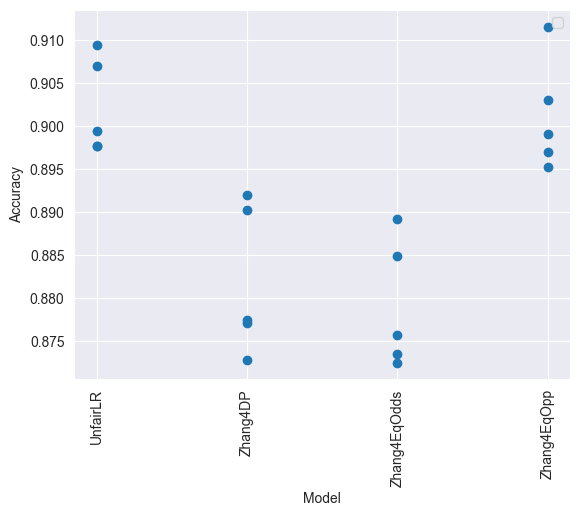

In [50]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [51]:
model_dps = unfair['dp'].to_list()+zhang['dp'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86277/2479496912.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


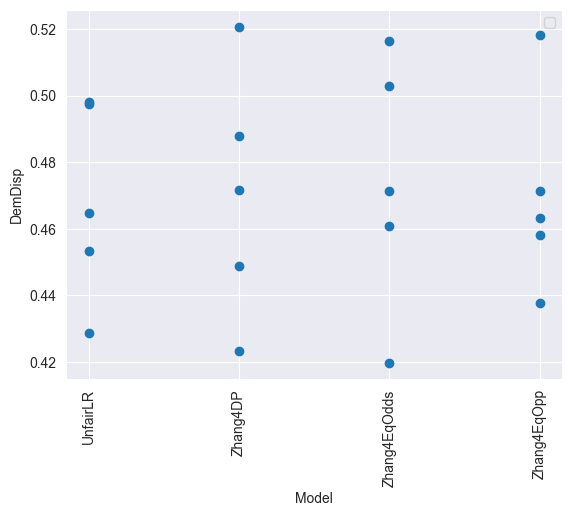

In [52]:
plt.plot()
plt.ylabel('DemDisp')

plt.scatter(model_names, model_dps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86277/1034882315.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


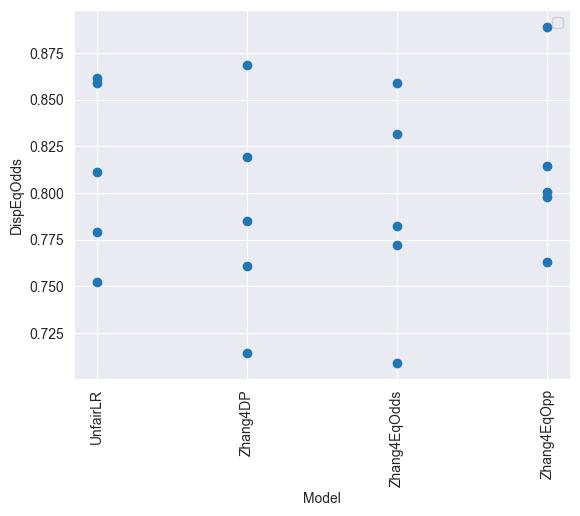

In [53]:
model_deqodds = unfair['deqodds'].to_list()+zhang['deqodds'].to_list()
plt.plot()
plt.ylabel('DispEqOdds')

plt.scatter(model_names, model_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86277/755552296.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


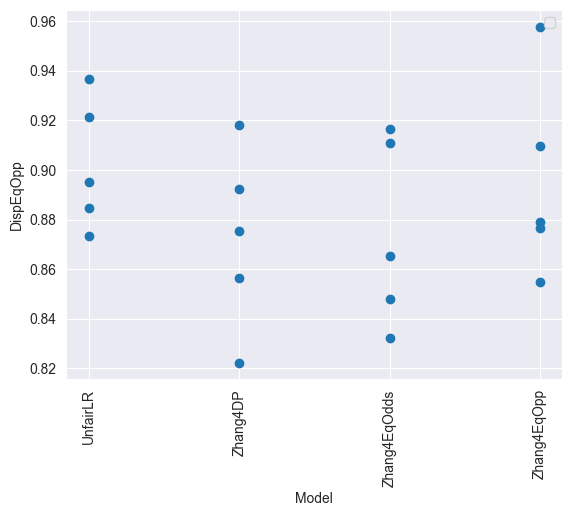

In [54]:
model_deqopps = unfair['deqopp'].to_list()+zhang['deqopp'].to_list()
plt.plot()
plt.ylabel('DispEqOpp')

plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DemDisp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86277/3481502659.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


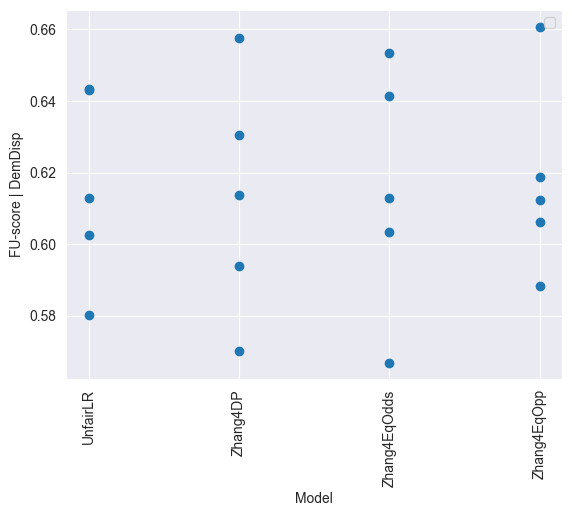

In [55]:
model_trade_dp = unfair['trade_dp'].to_list()+zhang['trade_dp'].to_list()
plt.plot()
plt.ylabel('FU-score | DemDisp')

plt.scatter(model_names, model_trade_dp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOdds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86277/1478964109.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


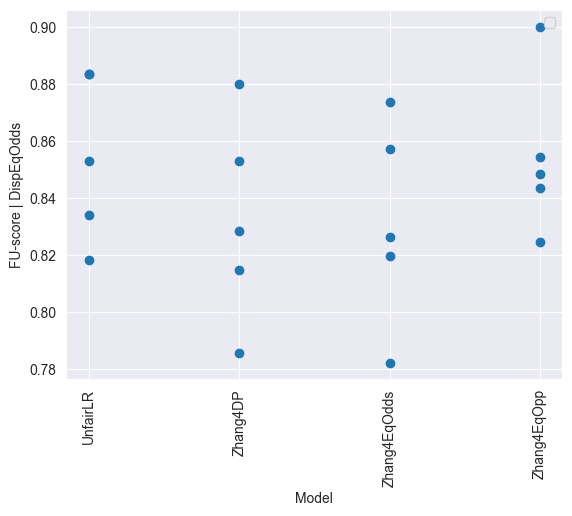

In [56]:
model_trade_deqodds = unfair['trade_deqodds'].to_list()+zhang['trade_deqodds'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOdds')

plt.scatter(model_names, model_trade_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOpp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86277/1705168636.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


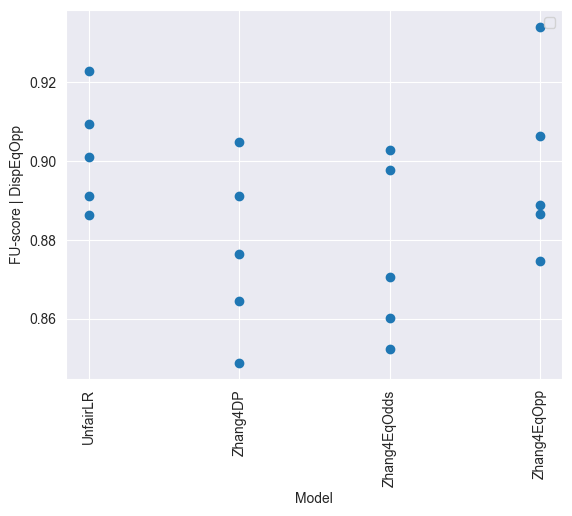

In [57]:
model_trade_deqopp = unfair['trade_deqopp'].to_list()+zhang['trade_deqopp'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOpp')

plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x DemDisp

In [58]:
'''cmap=sns.light_palette("seagreen")#,as_cmap=True)
cmap'''

'cmap=sns.light_palette("seagreen")#,as_cmap=True)\ncmap'

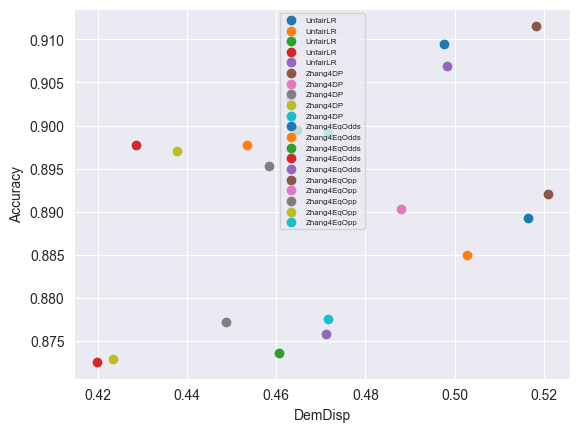

<Figure size 700x700 with 0 Axes>

In [59]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

plt.xlabel('DemDisp')
plt.ylabel('Accuracy')

for i, model_name in enumerate(model_names):
    plt.scatter(model_dps[i], model_accs[i], label=model_name)#, color=cmap[i])
plt.legend(loc='upper center', fontsize='xx-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x DispEqOdds

## Plotting Acc x DispEqOpp

# Pro artigo

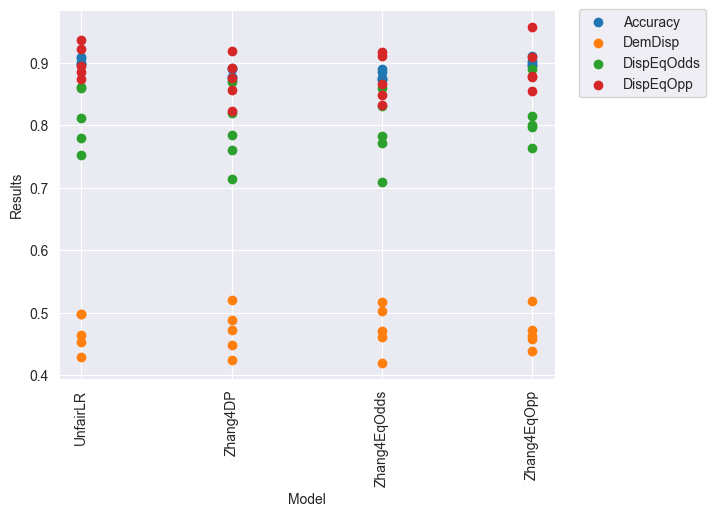

In [60]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_accs)
plt.scatter(model_names, model_dps)
plt.scatter(model_names, model_deqodds)
plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['Accuracy', 'DemDisp', 'DispEqOdds', 'DispEqOpp'], bbox_to_anchor=(1.32,1.02), loc="upper right")
plt.show()

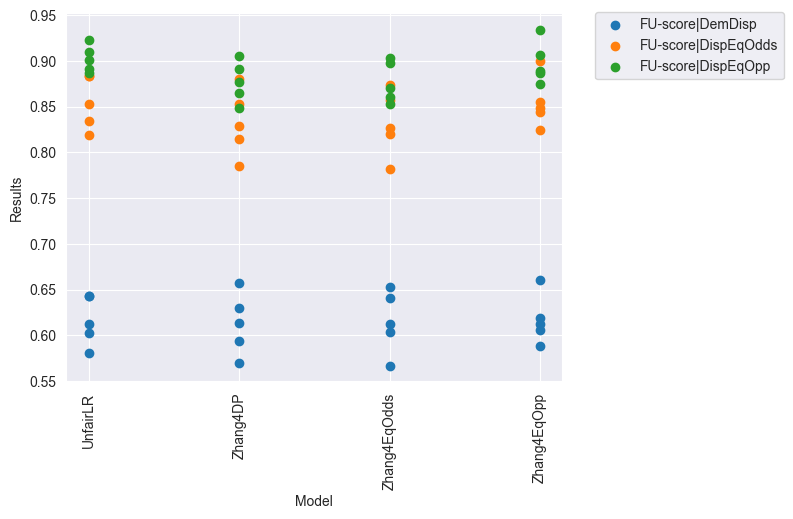

In [61]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_trade_dp)
plt.scatter(model_names, model_trade_deqodds)
plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['FU-score|DemDisp', 'FU-score|DispEqOdds', 'FU-score|DispEqOpp'], bbox_to_anchor=(1.46,1.02), loc="upper right")
plt.show()